In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

Data preprocessing and consolidation, with subsequent statistical analysis (std, min, max, and mean calculations)

In [2]:
def combine (data):
    """
        Put separated [x],[y],[z] value of each amino acids together 

        Args:
            data(pandas.core.frame.DataFrame): The seperated xyz position of 8 amino acids

        Returns:
            position(numpy.ndarray): [x,y,z] values of 8 amino acids
    """
    number = np.arange(0, 6000)
    name = ['Arg1', 'Ala1', 'His1','Pro1','Gly1','Gly2','Thr1','Ala2']
    position = np.zeros([6000,8,3]) # to store the x,y,z coordinates
    
    n = 0
    # gathering xyz coordinates into an array 
    for i in name:
        for j in range(0, 6000):
            x = data[f'{i}_x'][j]
            y = data[f'{i}_y'][j]
            z = data[f'{i}_z'][j]
            total = [x,y,z]
            position[j,n] = total
        n += 1
    return position
    

In [3]:
def distance_calculate (position):
    """
        Calculate distances between the pairs of amino acids

        Args:
            position(numpy.ndarray) : [x,y,z] values of 8 amino acids

        Returns:
            dis_ary(numpy.ndarray) : stores the distance values between pairs of amino acids
    """
    first_ele = position[:, :4, :]
    second_ele = position[:, 4:, :]
    diff = second_ele - first_ele
    

    # Calculate the distances between amino acids, store the value in an array
    dis_ary = np.linalg.norm(diff, axis=2)

    return dis_ary

In [4]:
def plotting (df, name):
    """
        Prints the histogram to show the distribution of distances 

        Args:  
            df(pandas.core.frame.DataFrame) : stores the distance values between pairs of amino acids
            name(string): csv file name
    """
        
    fig, ax = plt.subplots(figsize=(10,6))
    for col in df.columns:
        ax.hist(df[col], alpha = 0.5, label = col, bins=30)
    
    
    ax.set_xlabel('Distance(Ångstrom)')
    ax.set_ylabel('Numbers')

    ax.set_xlim(4,12) 
    ax.set_ylim(0,2000)

    ax.legend()
    ax.grid(True)
    ax.set_title(f'Distances Distribution of {len(df.columns)} pairs_{name}')
    plt.show()

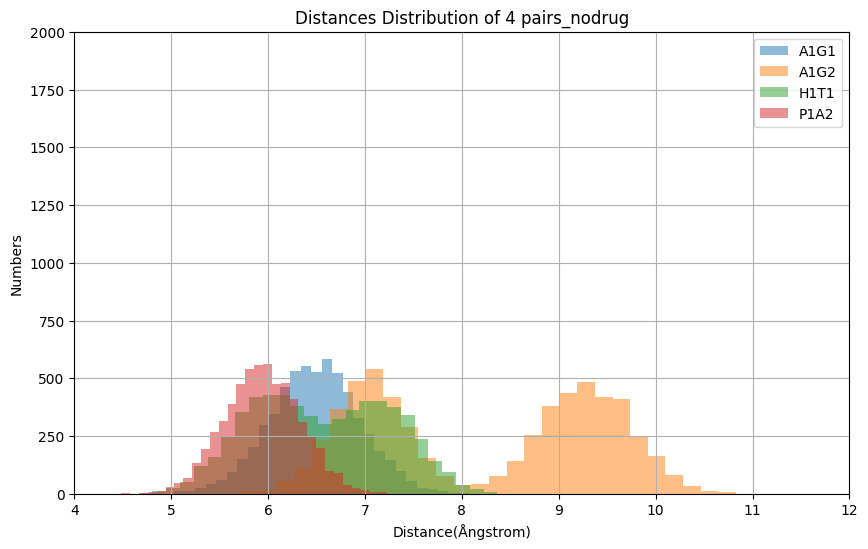

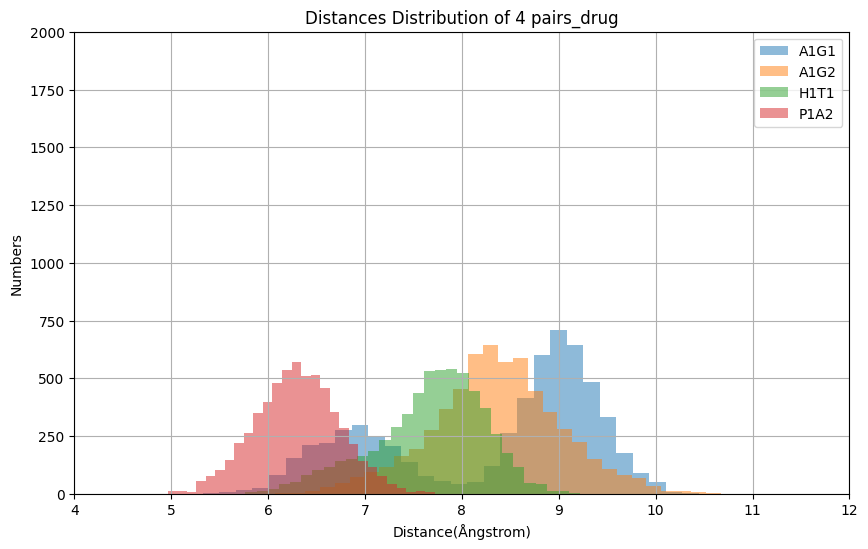

In [5]:
import pandas as pd
import numpy as np

def process_data(file_name, name):
    """
    calculate the distance between protein

    Args: 
        filename(string): csv file 
        name(string) : name of csv file

    Returns:
        df(pandas.core.frame.DataFrame) : stores the distance values between pairs of amino acids
    """

    data = pd.read_csv(file_name) 
    pos = combine(data)
    ary = distance_calculate(pos)
    
    cols = ['A1G1', 'A1G2', 'H1T1', 'P1A2']
    df = pd.DataFrame(ary, columns=cols, index=np.arange(1, len(ary)+1))
    

    plotting(df, name)
    return df

datasets = {
    'nodrug': 'no_drug.csv', 
    'drug': 'drug.csv'
}
results = {name: process_data(f, name) for name, f in datasets.items()}

nodrug_df = results['nodrug']
drug_df = results['drug']

In [6]:
def mean_std_max_min(dis_df):
    """
        Calculate mean, std, max and min values

        Arg:
            dis_df(pandas.core.frame.DataFrame): stores the distance values between pairs of amino acids
        Returns:
            total(pandas.core.frame.DataFrame): stores the mean, std, maximum and minimum value of 4  amino acid pairs
    """

    #calculate mean
    total = dis_df.agg(['mean', 'std', 'max', 'min']) # Specify a calculation list and automatically apply it to each column
    return total

Show the mean, std, max, min under drug and no drug condition

In [10]:
mean_std_max_min(nodrug_df)


,A1G1,A1G2,H1T1,P1A2
mean,6.485785,8.241277,6.556926,5.942877
std,0.459191,1.208398,0.704222,0.390145
max,8.076803,11.194853,8.651155,7.226664
min,4.812727,5.727562,4.377639,4.484578


In [11]:
mean_std_max_min(drug_df)

,A1G1,A1G2,H1T1,P1A2
mean,8.307212,8.357299,7.666684,6.299128
std,1.110831,0.661387,0.572483,0.432821
max,10.446384,10.670477,9.220949,7.719067
min,5.326288,6.074976,5.765648,4.764312


Start doing PCA 

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def run_pca_analysis(df, name="Data"):
    """
    perform PCA analysis and print statistical information 
    Return: (pca_object, pca_transformed_data)
    """
    # initialization and execute PCA
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(df)
    
    # Print out the results
    print(f"--- {name} Analysis ---")
    print(f"The components:\n{pca.components_}\n")
    print(f"The explained_variance_: {pca.explained_variance_}")
    print(f"The explained_variance_ratio: {pca.explained_variance_ratio_}\n")
    
    return pca, pca_data


#  No Drug 
pca_no, nodrug_pca = run_pca_analysis(nodrug_df, name="No Drug")
no_pc1, no_pc2 = nodrug_pca[:, 0], nodrug_pca[:, 1]

# Drug 
pca_yes, drug_pca = run_pca_analysis(drug_df, name="Drug")
pc1, pc2 = drug_pca[:, 0], drug_pca[:, 1]



--- No Drug Analysis ---
The components:
[[-0.05396631  0.89162177 -0.44879215 -0.02615056]
 [ 0.99814721  0.03550939 -0.04924126 -0.00406445]]

The explained_variance_: [1.79336229 0.20626454]
The explained_variance_ratio: [0.77325931 0.08893684]

--- Drug Analysis ---
The components:
[[ 0.95665453 -0.08115998  0.26709491  0.08297876]
 [ 0.22053053  0.82104892 -0.46180845 -0.25293856]]

The explained_variance_: [1.31216786 0.55916053]
The explained_variance_ratio: [0.60013677 0.25573923]




### Explained Variance Analysis

* **Baseline Condition**: The first two components account for over 85% of total variance, indicating that data features are highly concentrated in a low-dimensional subspace. 
  

* **Drug Condition**: The dominance of PC1 decreased, suggesting that data variation has become more dispersed across multiple components.


### Principal Component Contributions

* **Drug Effect on PC1**: Following drug treatment, "Variable 1" shifted from a minor contributor to the primary driver of variance.
* **Component Dominance**: This shift confirms that the drug treatment significantly reorganized the data structure, with Variable 1 now serving as the most dominant source of variation along PC1.

### Data Complexity & Dimensionality Analysis

* **Increased Complexity**: Drug treatment induced a more complex data structure, as evidenced by a threefold increase in PC2’s explained variance.
* **Emergent Factors**: This shift indicates that secondary factors, previously negligible in the baseline, have become significant drivers of variation in the drug-treated dataset.

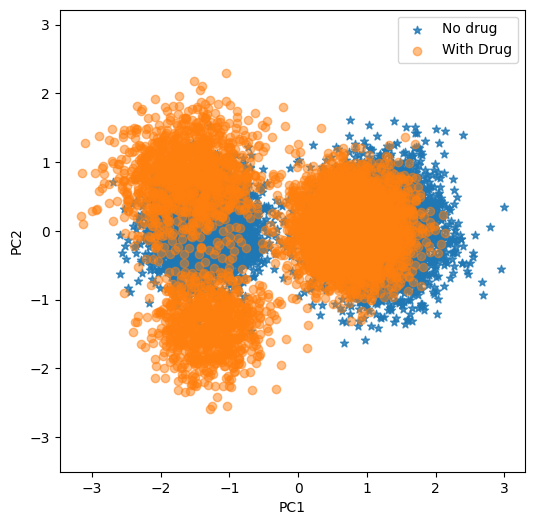

In [14]:
# Plotting 
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(no_pc1, no_pc2, marker = '*', alpha=0.8, label='No drug')
ax.scatter(pc1, pc2, marker = 'o',  alpha=0.5, label = 'With Drug')
ax.axis('equal')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.show()

### Population Response Analysis

* **Cluster Transformation**: Drug treatment induced a transition from a unified population to **three distinct clusters**, revealing heterogeneous response patterns.


* **Increased Complexity**: The importance of PC2 tripled, confirming that the drug triggers divergent phenotypic states rather than a uniform shift.

In [18]:
def kmeans_plot(drug_df, n_components):
    """
        Apply k-means algorithm to cluster data and print plot

        Arg:
            drug_df(pandas.core.frame.DataFrame): stores the distance values between pairs of amino acids with drug
            n_components(int): the component number for PCA and cluster number for k-means
    """
    # PCA & Kmeans
    pca_drug = PCA(n_components)
    pca_drug.fit(drug_df)
    drug_pca = pca_drug.transform(drug_df)
    
    X = drug_pca
    n_clusters = n_components

    kmeans = KMeans(n_clusters)
    kmeans.fit(X)
    labels = kmeans.labels_
    
    unique, counts = np.unique(labels, return_counts=True) # Quantify population distribution across identified clusters
    frequencies = counts / len(labels) * 100

    for label, freq in zip(unique, frequencies):
        if label == 0:
            print(f"cluster {label} (Purple): Frequency of occurrence {freq:.2f}%")
        elif label == 1:
            print(f"cluster {label} (Green): Frequency of occurrence {freq:.2f}%")
        elif label == 2:
            print(f"cluster {label} (Yellow): Frequency of occurrence {freq:.2f}%")
    

    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(X[:, 0], X[:, 1], c=labels)
    ax.scatter(X[0,0], X[0, 1], marker = 'o', label='first point')
    ax.scatter(X[-1,0], X[-1,1], marker = 's', label = 'last time point')
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color = 'red', marker='*', label = 'centre')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()
    
    plt.show()



cluster 0 (Purple): Frequency of occurrence 66.17%
cluster 1 (Green): Frequency of occurrence 33.83%


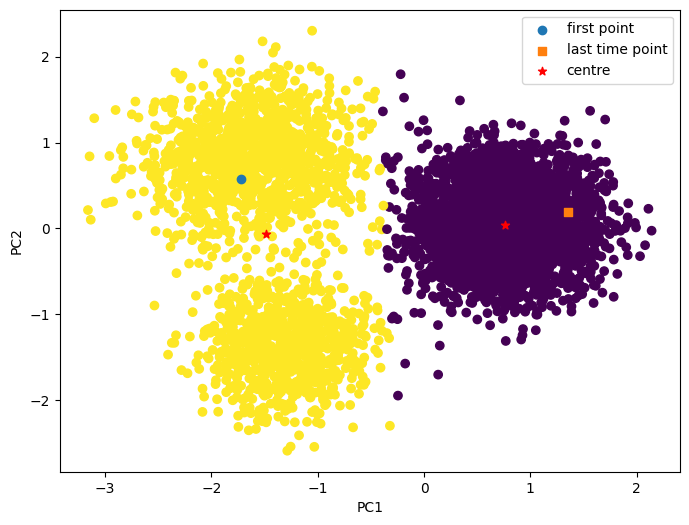

In [19]:
kmeans_plot(drug_df, n_components=2)

cluster 0 (Purple): Frequency of occurrence 66.05%
cluster 1 (Green): Frequency of occurrence 20.25%
cluster 2 (Yellow): Frequency of occurrence 13.70%


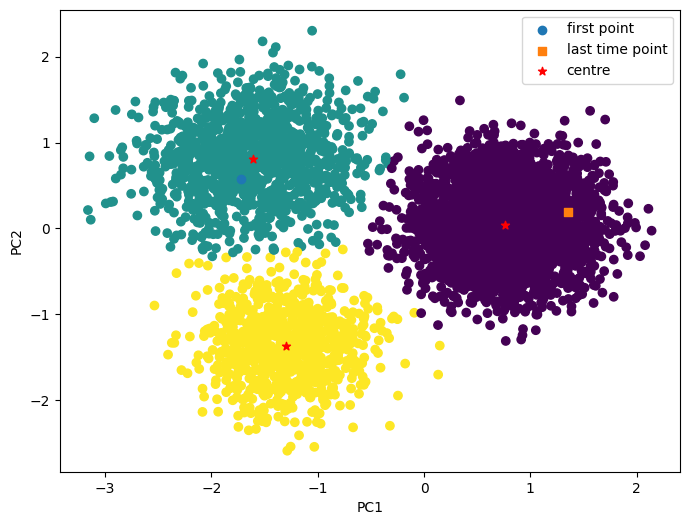

In [20]:
kmeans_plot(drug_df, n_components=3)

### Conformational Trajectory
* **Method**: PCA (PC1 & PC2) followed by K-Means clustering.
* **Pathway**: The transition from **Yellow (initial)** $\rightarrow$ **Green (intermediate)** $\rightarrow$ **Purple (final)** reveals the protein's structural evolution.

### Analysis & Clustering Workflow

* **K-Means Clustering**: Partitioned the PCA-transformed data into 3 distinct configurations to categorize structural states.
* **Silhouette Score**: Evaluated the quality of cluster separation, where a higher value indicates more distinct and well-defined structural groups.

* **Frequency Analysis**: Quantified the percentage distribution of each structural configuration, revealing how often the system resides in each state.
* **Representative Frames**: Identified the index of the frame closest to each cluster center, providing a reference point to retrieve and review the original coordinates for each specific configuration.

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, pairwise_distances_argmin_min
import pandas as pd
n_components = 3
pca_drug = PCA(n_components)
pca_drug.fit(drug_df)
drug_pca = pca_drug.transform(drug_df)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(drug_pca)

score = silhouette_score(drug_pca, labels)
print(f"Silhouette Score (classification quality)): {score:.3f}")


counts = pd.Series(labels).value_counts(normalize=True).sort_index() * 100
print("\n Frequency of each configuration (%):")
for cluster_id, percentage in counts.items():
    print(f"Configuration {cluster_id}: {percentage:.2f}%")

closest_indices, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, drug_pca)
print("\n The index of each configuration represents the frame (which can be used to review the original coordinates).")
for cluster_id, frame_idx in enumerate(closest_indices):
    print(f"The representative frame index of the configuration {cluster_id} is: {frame_idx}")

Silhouette Score (classification quality)): 0.607

 Frequency of each configuration (%):
Configuration 0: 66.05%
Configuration 1: 13.70%
Configuration 2: 20.25%

 The index of each configuration represents the frame (which can be used to review the original coordinates).
The representative frame index of the configuration 0 is: 2810
The representative frame index of the configuration 1 is: 1512
The representative frame index of the configuration 2 is: 584


**Apply GMM**

**compare k- mean result with gaussian result** 


In [23]:
def gaussian_plot(drug_df, n_components):
    """
        Apply gaussian algorithm to cluster data and print plot

        Arg:
            drug_df(pandas.core.frame.DataFrame): stores the distance values between pairs of amino acids with drug
            n_components(int): the component number for PCA and cluster number for gaussian
    """
    pca_drug = PCA(n_components)
    pca_drug.fit(drug_df)
    drug_pca = pca_drug.transform(drug_df)
    
    X = drug_pca
    gmm = GaussianMixture(n_components).fit(X)
    labels = gmm.predict(X)
    probs = gmm.predict_proba(X)
    size = 10 * probs.max(axis=1)**2
    
    
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(X[:, 0], X[:, 1], c=labels, s = size)
    ax.scatter(X[0,0], X[0, 1], marker = 'o', label='first point')
    ax.scatter(X[-1,0], X[-1,1], marker = 's', label = 'last time point')
    ax.axis('equal')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()
    plt.show()


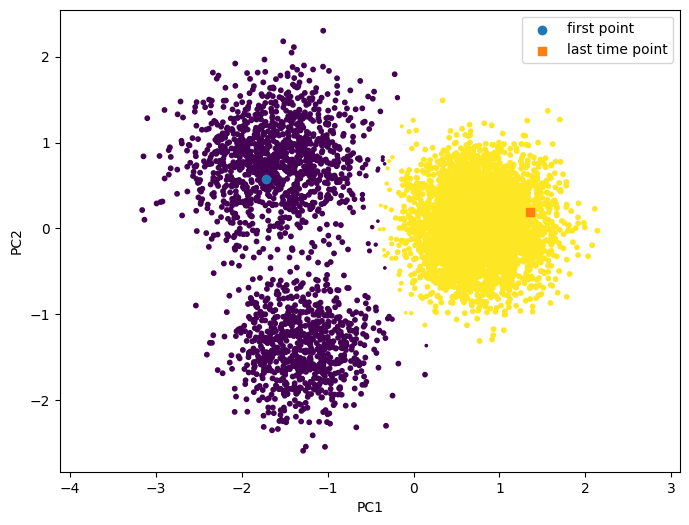

In [24]:
gaussian_plot(drug_df, n_components=2)

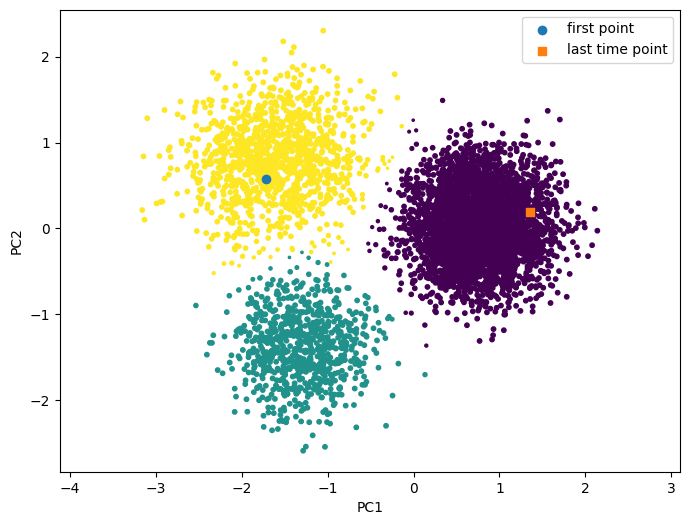

In [25]:
gaussian_plot(drug_df, n_components=3)

Results are the same -> clusters are stable